Primera vez utilizando una IDE y con poco conocimiento en programación, veamos:

Bien, mi idea es trabajar con un dataset de la NBA proveniente de un sitio web llamado NBAstuffer que se ha convertido en una referencia estadística de buena reputación que ofrece métricas únicas y contenido analítico de dicha liga.

Importo las librerías

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans, DBSCAN

Cargo el dataset en una variable y lo pruebo

In [ ]:
df = pd.read_excel("/content/NBA_2015-16_RS_Player_Stats.xlsx")
df.head()

,Header,Rank,PLAYER,TEAM,POS,AGE,GP,MPG,MIN%,USG%,...,3P%,TS%,PPG,RPG,TRB%,APG,AST%,SPG,BPG,VI
0,2015-2016 NBA REGULAR SEASON PLAYER STATS,NaN,Aaron Brooks,Chi,PG,31,69,16.1,33.4,23.0,...,0.357,0.493,7.1,1.5,4.8,2.6,26.0,0.43,0.14,7.5
1,2015-2016 NBA REGULAR SEASON PLAYER STATS,NaN,Andre Miller,Min,PG,39,26,10.8,22.5,14.6,...,0.250,0.663,3.4,0.9,5.0,2.2,31.8,0.35,0.00,7.0
2,2015-2016 NBA REGULAR SEASON PLAYER STATS,NaN,Andre Miller,San,PG,39,13,13.9,29.0,16.7,...,0.250,0.521,4.3,2.1,8.5,2.2,22.7,0.54,0.00,7.8
3,2015-2016 NBA REGULAR SEASON PLAYER STATS,NaN,Andrew Goudelock,Hou,PG,27,8,6.2,12.9,24.9,...,0.111,0.506,2.8,0.3,2.2,0.5,13.4,0.75,0.25,4.8
4,2015-2016 NBA REGULAR SEASON PLAYER STATS,NaN,Beno Udrih,Mia,PG,33,36,16.3,34.0,15.7,...,0.333,0.495,4.4,1.8,6.1,2.5,22.5,0.31,0.00,6.6


# DICCIONARIO:

HEADER: Columna creada por error al migrar la tabla de la web al excel. Es en realidad el nombre de la tabla. Principal candidata a ser removida en pasos posteriores del TP.

RANK: Columna en desuso que da un orden a los jugadores (columna "player") que ya se encuentran ordenados alfabéticamente. Podría ser removida en pasos posteriores del TP.

PLAYER: Nombre y Apellido del jugador.

TEAM: Equipo en el cual se desempeñó el jugador.

POS: Posición principal en la que se desempeña el jugador.

AGE: Edad del jugador.

GP: Partidos Jugados (Máx: 82)

MPG: Minutos por juego (Máx: 48)




MIN%: Porcentaje del juego en el que el jugador estuvo presente.

USG%: Porcentaje que indica el uso ofensivo del jugador en su equipo. Este valor toma en cuenta la cantidad de jugadas que finaliza el jugador con un tiro de campo, un tiro libre o una pérdida de balón.

TOr: Ratio de pérdidas de balón por posesión del balón.

FTA: Tiros libres intentados.

FT%: Porcentaje de acierto de tiros libres.

2PA: Tiros de 2 puntos intentados.

2P%: Porcentaje de acierto en tiros de 2 puntos.

3PA: Tiros de 3 puntos intentados.

3P%: Porcentaje de acierto en tiros de 3 puntos.

TS%: Mide la eficiencia de un jugador al lanzar el balón. Toma en cuenta la efectividad de los tiros de campo, los tiros libres y los triples.

PPG: Puntos realizados por partido.

RPG: Rebotes obtenidos por partido.

TRB%: Porcentaje de rebotes que un jugador captura en relación con el total de rebotes disponibles.

APG: Asistencias completadas por partido.

AST%: Estimación del porcentaje de tiros de campo de los compañeros de equipo que un jugador asistió mientras estaba en la cancha.

SPG: Robos obtenidos por partido.

BPG: Bloqueos realizados por partido.

VI: El Indice de Versatilidad es una métrica que mide la habilidad del jugador para producir puntos, rebotes y asistencias. Se obtiene calculando la raíz cúbica de PPGx40/MPG, APGx40/MPG, y RPGx40/MPG.
*Un jugador promedio consigue alrededor de 5 puntos, mientras que los mejores jugadores pasan los 10.*

# INTERÉS DE LA INVESTIGACIÓN:

Quiero analizar la temporada 2015-2016 en donde Golden State Warriors rompió el récord de victorias en temporada regular (sostenido hasta ese entonces por Los Chicago Bulls del 1995-96) y Stephen Curry ganó el premio al MVP de manera unánime.


**Objetivo:** Clasificar jugadores de la temporada 2015-2016 en grupos según su juego utilizando técnicas de clustering.

           + Predicción del rendimiento de un jugador en función de sus estadísticas.

**Tipo de Aprendizaje:** No Supervisado.

# EXPLORACIÓN DEL DATASET:

In [ ]:
df.head()
df.tail()
df.shape
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497 entries, 0 to 496
Data columns (total 26 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Header  497 non-null    object 
 1   Rank    0 non-null      float64
 2   PLAYER  497 non-null    object 
 3   TEAM    497 non-null    object 
 4   POS     497 non-null    object 
 5   AGE     497 non-null    int64  
 6   GP      497 non-null    int64  
 7   MPG     497 non-null    float64
 8   MIN%    497 non-null    float64
 9   USG%    497 non-null    float64
 10  TOr     497 non-null    float64
 11  FTA     497 non-null    int64  
 12  FT%     497 non-null    float64
 13  2PA     497 non-null    int64  
 14  2P%     497 non-null    float64
 15  3PA     497 non-null    int64  
 16  3P%     497 non-null    float64
 17  TS%     497 non-null    float64
 18  PPG     497 non-null    float64
 19  RPG     497 non-null    float64
 20  TRB%    497 non-null    float64
 21  APG     497 non-null    float64
 22  AS

Index(['Header', 'Rank', 'PLAYER', 'TEAM', 'POS', 'AGE', 'GP', 'MPG', 'MIN%',
       'USG%', 'TOr', 'FTA', 'FT%', '2PA', '2P%', '3PA', '3P%', 'TS%', 'PPG',
       'RPG', 'TRB%', 'APG', 'AST%', 'SPG', 'BPG', 'VI'],
      dtype='object')

**Exploración de variables numéricas:**

In [ ]:
df.describe()

,Rank,AGE,GP,MPG,MIN%,USG%,TOr,FTA,FT%,2PA,...,3P%,TS%,PPG,RPG,TRB%,APG,AST%,SPG,BPG,VI
count,0.0,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000,...,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000
mean,NaN,26.863179,51.967807,20.603219,42.919316,18.729980,0.134485,115.424547,0.733372,299.022133,...,0.273247,0.523905,8.489738,3.671227,9.943058,1.896579,13.483099,0.666499,0.411751,6.599799
std,NaN,4.327495,24.767690,8.667388,18.060041,4.989393,0.053113,125.292202,0.150473,270.648261,...,0.154459,0.069071,5.506330,2.354465,4.706014,1.750912,9.281079,0.429101,0.434549,1.894437
min,NaN,19.000000,2.000000,5.000000,10.500000,1.900000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,24.000000,30.000000,13.900000,29.000000,15.300000,0.104000,29.000000,0.674000,75.000000,...,0.222000,0.493000,4.300000,2.000000,6.200000,0.700000,7.200000,0.350000,0.130000,5.500000
50%,NaN,26.000000,59.000000,20.200000,42.100000,18.100000,0.129000,66.000000,0.758000,225.000000,...,0.324000,0.532000,7.100000,3.100000,8.700000,1.400000,10.300000,0.580000,0.280000,6.500000
75%,NaN,30.000000,75.000000,28.000000,58.400000,21.700000,0.158000,161.000000,0.826000,437.000000,...,0.369000,0.564000,11.700000,4.800000,13.100000,2.400000,17.900000,0.880000,0.510000,7.700000
max,NaN,39.000000,82.000000,38.100000,79.400000,35.400000,0.510000,837.000000,1.000000,1238.000000,...,1.000000,0.694000,30.100000,14.800000,30.300000,11.700000,52.600000,2.140000,3.680000,14.500000


Con estas métricas podemos identificar que:

Tenemos 497 jugadores.

La edad promedio es de 26,86 años.
  Cuyo rango se extiende desde los 19 años hasta los 39 .
  La mayoría ubicados en el rango de 24 a 30.

Entre todos los jugadores en observación hay un promedio de casi 52 partidos jugados de los 82 disponibles, aunque hay algunos que lograron jugar toda la temporada sin perderse ni un sólo partido y otros que únicamente vieron minutos en 2 partidos.

**Exploración de variables categóricas:**

In [ ]:
df['PLAYER'].value_counts()

,count
PLAYER,
Kris Humphries,3
Markieff Morris,2
JaKarr Sampson,2
Justin Holiday,2
Josh Smith,2
...,...
Lamar Patterson,1
Kyle Korver,1
Klay Thompson,1


Esto nos demuestra que hay valores repetidos para algunos jugadores.


Si nos fijamos, podemos entender que se debe a que jugaron para distintos equipos durante la misma temporada. *Por ejemplo, Anderson Varejao jugó tanto para los Cleveland Cavaliers como para los Golden State Warriors.*

# LIMPIEZA DE DATOS:

In [ ]:
# Verifico la cantidad de valores nulos por columna
df.isnull().sum()

,0
Header,0
Rank,497
PLAYER,0
TEAM,0
POS,0
AGE,0
GP,0
MPG,0
MIN%,0
USG%,0


In [ ]:
# Verifico duplicados
df.duplicated().sum()

0

In [ ]:
#Identifico outliers
Q1 = df['PPG'].quantile(0.25)
Q3 = df['PPG'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['PPG'] < (Q1 - 1.5 * IQR)) | (df['PPG'] > (Q3 + 1.5 * IQR))]
print(outliers)

                                        Header  Rank             PLAYER TEAM  \
19   2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN     Damian Lillard  Por   
83   2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN  Russell Westbrook  Okc   
91   2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN      Stephen Curry  Gol   
130  2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN      DeMar DeRozan  Tor   
150  2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN       James Harden  Hou   
259  2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN       Kevin Durant  Okc   
267  2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN       LeBron James  Cle   
308  2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN      Anthony Davis  Nor   
387  2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN        Paul George  Ind   
437  2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN   DeMarcus Cousins  Sac   

    POS  AGE  GP   MPG  MIN%  USG%  ...    3P%    TS%   PPG   RPG  TRB%   APG  \
19   PG   25  75  35.7  74.3  31.3  ..

In [ ]:
#Identifico otros outliers
Q1 = df['APG'].quantile(0.25)
Q3 = df['APG'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['APG'] < (Q1 - 1.5 * IQR)) | (df['APG'] > (Q3 + 1.5 * IQR))]
print(outliers)

                                        Header  Rank                   PLAYER  \
13   2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN               Chris Paul   
19   2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN           Damian Lillard   
23   2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN           Deron Williams   
27   2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN            Elfrid Payton   
29   2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN          Emmanuel Mudiay   
30   2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN             Eric Bledsoe   
35   2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN            Isaiah Thomas   
36   2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN                Ish Smith   
37   2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN                Ish Smith   
39   2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN             Jarrett Jack   
40   2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN              Jeff Teague   
44   2015-2016 NBA REGULAR S

In [ ]:
#Identifico otros outliers
Q1 = df['RPG'].quantile(0.25)
Q3 = df['RPG'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['RPG'] < (Q1 - 1.5 * IQR)) | (df['RPG'] > (Q3 + 1.5 * IQR))]
print(outliers)

                                        Header  Rank              PLAYER TEAM  \
308  2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN       Anthony Davis  Nor   
330  2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN      Draymond Green  Gol   
354  2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN       Julius Randle  Lal   
358  2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN          Kevin Love  Cle   
417  2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN      Andre Drummond  Det   
435  2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN      DeAndre Jordan  Lac   
437  2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN    DeMarcus Cousins  Sac   
439  2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN       Dwight Howard  Hou   
445  2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN    Hassan Whiteside  Mia   
461  2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN   Jonas Valanciunas  Tor   
463  2015-2016 NBA REGULAR SEASON PLAYER STATS   NaN  Karl-Anthony Towns  Min   
469  2015-2016 NBA REGULAR S

**Manipulación de limpieza:**

Eliminación de Columnas con Valores Nulos

In [ ]:
# Identifico columnas con valores nulos
df.isnull().sum() > 0

,0
Header,False
Rank,True
PLAYER,False
TEAM,False
POS,False
AGE,False
GP,False
MPG,False
MIN%,False
USG%,False


In [ ]:
# Columnas con valores nulos
df.dropna(axis=1, inplace=True)

Conversión de tipos de datos:

In [ ]:
# Columna a tipo categórico
df['TEAM'] = df['TEAM'].astype('category')
df['POS'] = df['POS'].astype('category')

In [ ]:
# Columna a tipo numérico
df['AGE'] = pd.to_numeric(df['AGE'])
df['GP'] = pd.to_numeric(df['GP'])
df['MPG'] = pd.to_numeric(df['MPG'])
df['MIN%'] = pd.to_numeric(df['MIN%'])
df['USG%'] = pd.to_numeric(df['USG%'])
df['TOr'] = pd.to_numeric(df['TOr'])
df['FTA'] = pd.to_numeric(df['FTA'])
df['FT%'] = pd.to_numeric(df['FT%'])
df['2PA'] = pd.to_numeric(df['2PA'])
df['2P%'] = pd.to_numeric(df['2P%'])
df['3PA'] = pd.to_numeric(df['3PA'])
df['3P%'] = pd.to_numeric(df['3P%'])
df['TS%'] = pd.to_numeric(df['TS%'])
df['PPG'] = pd.to_numeric(df['PPG'])
df['RPG'] = pd.to_numeric(df['RPG'])
df['TRB%'] = pd.to_numeric(df['TRB%'])
df['APG'] = pd.to_numeric(df['APG'])
df['AST%'] = pd.to_numeric(df['AST%'])
df['SPG'] = pd.to_numeric(df['SPG'])
df['BPG'] = pd.to_numeric(df['BPG'])
df['VI'] = pd.to_numeric(df['VI'])

**Identificación de outliers con un gráfico de dispersión:**

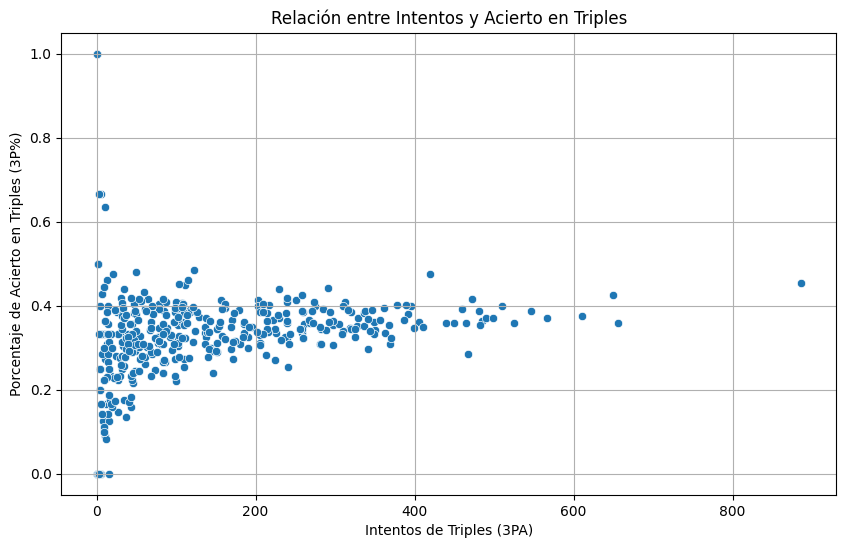

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["3PA"], y=df["3P%"])
plt.xlabel("Intentos de Triples (3PA)")
plt.ylabel("Porcentaje de Acierto en Triples (3P%)")
plt.title("Relación entre Intentos y Acierto en Triples")
plt.grid(True)
plt.show()

Este gráfico nos muestra la relación entre los tiros de 3 puntos tomados por cada jugador y su porcentaje de acierto.

Stephen Curry, jugador estrella de los Warriors de Golden State, es el punto más a la derecha en el gráfico. Rompió el récord de triples durante esta temporada regular con un total de 886 triples intentados y un sorprendente 45,4% de acierto.

*Antes de Curry, romper la barrera de los 300 triples en una temporada parecía inalcanzable. Su propia marca anterior era 286, y el récord histórico pertenecía previamente a Ray Allen con 269. Luego llegó la temporada 2015-16, y Curry no solo superó esos números... los destrozó con 402 triples. Un incremento de más del 40% sobre cualquier marca previa.*

*Para ponerlo en perspectiva, Ray Allen necesitó 17 temporadas para llegar a 2,973 triples en su carrera. Curry metió casi el 15% de eso en una sola temporada.*

# CÁLCULO DE PER

El Player Efficiency Rating (PER) va a ser nuestro criterio para calcular la eficiencia de cada jugador. Usa varias estadísticas, y aunque el cálculo completo es complejo, una aproximación simplificada incluye componentes como PPG, APG, RPG y TS%, junto con la media de minutos jugados. Cosas que sí tenemos:

PER ≈ ( PPG×0.4+APG×0.3+RPG×0.2+TS%×0.1) / MPG

In [ ]:
# Calcular PER aproximado
df['PER'] = (df['PPG'] * 0.4 + df['APG'] * 0.3 + df['RPG'] * 0.2 + df['TS%'] * 0.1) / df['MPG']


# Normalización de Variables

Usando StandardScaler, ajustaré las variables para que todas las columnas tengan un impacto similar en el clustering.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Seleccionar las columnas numéricas para normalizar
columns_to_normalize = ['AGE', 'GP', 'MPG', 'MIN%', 'USG%', 'TOr', 'FTA', 'FT%', '2PA', '2P%', '3PA', '3P%', 'TS%', 'PPG', 'APG', 'AST%', 'RPG', 'TRB%', 'SPG', 'BPG', 'VI', 'PER']

# Crear un objeto StandardScaler
scaler = StandardScaler()

# Aplicar la normalización
df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])


In [ ]:
# Verifico el dataframe para comprobar el cálculo del PER y la normalización
df.head()


,Header,PLAYER,TEAM,POS,AGE,GP,MPG,MIN%,USG%,TOr,...,TS%,PPG,RPG,TRB%,APG,AST%,SPG,BPG,VI,PER
0,2015-2016 NBA REGULAR SEASON PLAYER STATS,Aaron Brooks,Chi,PG,0.956902,0.688371,-0.520082,-0.527624,0.856682,0.122789,...,-0.447897,-0.252644,-0.923104,-1.093970,0.402150,1.350006,-0.551705,-0.625993,0.475660,0.487921
1,2015-2016 NBA REGULAR SEASON PLAYER STATS,Andre Miller,Min,PG,2.807409,-1.049511,-1.132186,-1.131774,-0.828586,2.629413,...,2.015827,-0.925274,-1.178195,-1.051429,0.173467,1.975563,-0.738329,-0.948491,0.211464,-0.170610
2,2015-2016 NBA REGULAR SEASON PLAYER STATS,Andre Miller,San,PG,2.807409,-1.574918,-0.774163,-0.771501,-0.407269,0.914354,...,-0.042107,-0.761662,-0.668012,-0.306950,0.173467,0.994086,-0.295097,-0.948491,0.634178,-0.254152
3,2015-2016 NBA REGULAR SEASON PLAYER STATS,Andrew Goudelock,Hou,PG,0.031649,-1.776997,-1.663446,-1.663870,1.237873,2.045162,...,-0.259494,-1.034350,-1.433287,-1.647012,-0.798433,-0.008963,0.194791,-0.372601,-0.951001,0.059707
4,2015-2016 NBA REGULAR SEASON PLAYER STATS,Beno Udrih,Mia,PG,1.419529,-0.645353,-0.496984,-0.494368,-0.607896,1.385524,...,-0.418912,-0.743482,-0.795558,-0.817450,0.344979,0.972515,-0.831642,-0.948491,0.000106,-0.722090


# CLUSTERING

Para decir cuántos clusters quiero, utilizaré el método del codo:

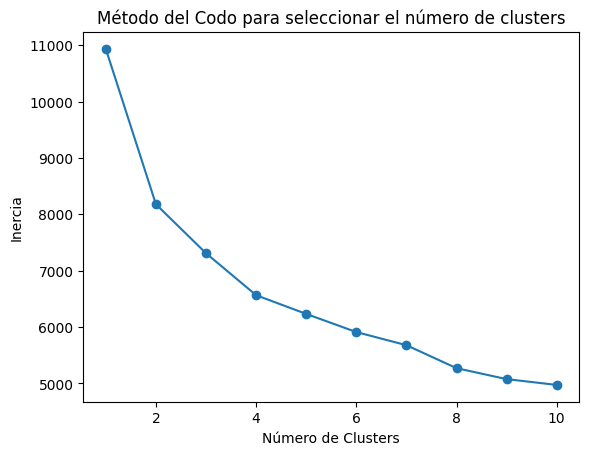

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Selecciono las columnas a usar para el clustering (las variables normalizadas)
columns_for_clustering = ['AGE', 'GP', 'MPG', 'MIN%', 'USG%', 'TOr', 'FTA', 'FT%', '2PA', '2P%', '3PA', '3P%', 'TS%', 'PPG', 'APG', 'AST%', 'RPG', 'TRB%', 'SPG', 'BPG', 'VI', 'PER']

# Creo una lista para guardar los valores de la inercia
inertia = []

# Pruebo con diferentes valores de K (número de clusters)
for k in range(1, 11):  # Probar entre 1 y 10 clusters
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df[columns_for_clustering])
    inertia.append(kmeans.inertia_)

# Graficar el método del codo
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Método del Codo para seleccionar el número de clusters')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.show()


Puedo ver que en a partir de 3, la inercia empieza a bajar rápidamente entonces esa será la cantidad de clusters que usaremos para dividir a los jugadores.

K-MEANS

In [ ]:
# Defino el número de clusters (K) elegido
k = 3

# Aplico K-Means
kmeans = KMeans(n_clusters=k, random_state=42)
df['Cluster'] = kmeans.fit_predict(df[columns_for_clustering])

# Ver los primeros resultados
df[['PLAYER', 'Cluster']].head()


,PLAYER,Cluster
0,Aaron Brooks,2
1,Andre Miller,0
2,Andre Miller,0
3,Andrew Goudelock,0
4,Beno Udrih,0


VISUALIZACIÓN DE LOS CLUSTERS:

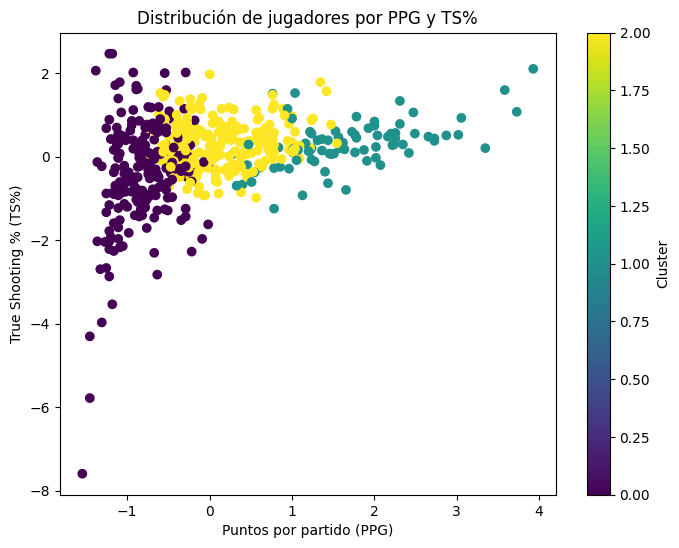

In [ ]:
# Grafico los clusters con PPG vs TS%
plt.figure(figsize=(8,6))
plt.scatter(df['PPG'], df['TS%'], c=df['Cluster'], cmap='viridis')
plt.title('Distribución de jugadores por PPG y TS%')
plt.xlabel('Puntos por partido (PPG)')
plt.ylabel('True Shooting % (TS%)')
plt.colorbar(label='Cluster')
plt.show()


En este gráfico, podemos considerar a los jugadores que se encuentran más a la "derecha" (puntos verdes) como superestrellas o jugadores de alto rendimiento ofensivo, debido al alto nivel de producción (PPG) y eficiencia (TS%).
En el grupo del medio tenemos jugadores que tienen un rendimiento mas equilibrado (puntos amarillos), pueden ser titulares, o jugadores que salgan del banco y tengan protagonismo/cumplan un importante rol en el equipo.
Finalmente, en el primer tercio del gráfico figuran jugadores con bajo nivel de anotación (puntos violáceos). Aunque esto no quita que puedan destacar en otros aspectos del juego.

**Ahora veamos que jugadores entraron en cada categoría**

In [ ]:
# Asignamos los clusters al DataFrame
df['Cluster'] = kmeans.labels_

In [ ]:
df[df['Cluster'] == 0]

,Header,PLAYER,TEAM,POS,AGE,GP,MPG,MIN%,USG%,TOr,...,PPG,RPG,TRB%,APG,AST%,SPG,BPG,VI,PER,Cluster
1,2015-2016 NBA REGULAR SEASON PLAYER STATS,Andre Miller,Min,PG,2.807409,-1.049511,-1.132186,-1.131774,-0.828586,2.629413,...,-0.925274,-1.178195,-1.051429,0.173467,1.975563,-0.738329,-0.948491,0.211464,-0.170610,0
2,2015-2016 NBA REGULAR SEASON PLAYER STATS,Andre Miller,San,PG,2.807409,-1.574918,-0.774163,-0.771501,-0.407269,0.914354,...,-0.761662,-0.668012,-0.306950,0.173467,0.994086,-0.295097,-0.948491,0.634178,-0.254152,0
3,2015-2016 NBA REGULAR SEASON PLAYER STATS,Andrew Goudelock,Hou,PG,0.031649,-1.776997,-1.663446,-1.663870,1.237873,2.045162,...,-1.034350,-1.433287,-1.647012,-0.798433,-0.008963,0.194791,-0.372601,-0.951001,0.059707,0
4,2015-2016 NBA REGULAR SEASON PLAYER STATS,Beno Udrih,Mia,PG,1.419529,-0.645353,-0.496984,-0.494368,-0.607896,1.385524,...,-0.743482,-0.795558,-0.817450,0.344979,0.972515,-0.831642,-0.948491,0.000106,-0.722090,0
5,2015-2016 NBA REGULAR SEASON PLAYER STATS,Beno Udrih,Mem,PG,1.419529,-1.776997,-0.635574,-0.638477,0.595867,1.027435,...,-0.470794,-1.093165,-1.200324,0.802344,2.460909,-0.668345,-0.649028,0.422821,0.365446,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
487,2015-2016 NBA REGULAR SEASON PLAYER STATS,Tarik Black,Lal,C,-0.662292,-0.524105,-0.912753,-0.910068,-1.169652,0.311257,...,-0.925274,0.139779,1.501069,-0.855604,-0.893371,-0.715001,0.111145,-0.581126,-0.638728,0
488,2015-2016 NBA REGULAR SEASON PLAYER STATS,Tiago Splitter,Atl,C,0.956902,-0.645353,-0.520082,-0.522081,-0.648022,-0.272994,...,-0.525332,-0.157828,0.288633,-0.626921,-0.602163,-0.248441,-0.188317,-0.264090,-0.372756,0
489,2015-2016 NBA REGULAR SEASON PLAYER STATS,Tibor Pleiss,Uta,C,-0.199665,-1.615333,-1.594151,-1.591815,0.094299,1.913235,...,-1.179783,-1.008134,0.161008,-0.969945,-1.022796,-1.368186,-0.556886,-1.003841,-0.858129,0
492,2015-2016 NBA REGULAR SEASON PLAYER STATS,Tyler Zeller,Bos,C,-0.199665,0.324628,-1.016695,-1.015378,0.856682,-0.272994,...,-0.434436,-0.285374,0.714049,-0.798433,-0.742374,-1.158234,-0.096175,0.264303,0.996948,0


In [ ]:
df[df['Cluster'] == 1]

,Header,PLAYER,TEAM,POS,AGE,GP,MPG,MIN%,USG%,TOr,...,PPG,RPG,TRB%,APG,AST%,SPG,BPG,VI,PER,Cluster
13,2015-2016 NBA REGULAR SEASON PLAYER STATS,Chris Paul,Lac,PG,0.725589,0.890450,1.397072,1.395681,1.679253,-0.009139,...,2.001579,0.224809,-0.626012,4.632776,4.218940,3.204106,-0.533850,2.536394,2.483039,1
18,2015-2016 NBA REGULAR SEASON PLAYER STATS,D’Angelo Russell,Lal,PG,-1.818859,1.132945,0.877362,0.880213,1.057309,0.462031,...,0.856289,-0.115313,-0.732367,0.802344,0.832304,1.151240,-0.579921,0.475660,0.518632,1
19,2015-2016 NBA REGULAR SEASON PLAYER STATS,Damian Lillard,Por,PG,-0.430978,0.930866,1.743546,1.739326,2.521887,-0.159913,...,3.019615,0.139779,-0.817450,2.803316,2.180487,0.474728,-0.096175,1.743804,2.566145,1
22,2015-2016 NBA REGULAR SEASON PLAYER STATS,Dennis Schroder,Atl,PG,-1.124919,1.132945,-0.035019,-0.039869,2.020319,0.763580,...,0.456346,-0.455435,-0.647283,1.431221,2.450124,0.498056,-0.695099,1.743804,1.624918,1
23,2015-2016 NBA REGULAR SEASON PLAYER STATS,Deron Williams,Dal,PG,0.956902,0.526707,1.362425,1.362425,0.656055,0.254716,...,1.019901,-0.327890,-1.051429,2.231610,1.705926,0.638024,-0.441708,0.528500,0.501818,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
448,2015-2016 NBA REGULAR SEASON PLAYER STATS,Jahlil Okafor,Phi,C,-1.587545,0.041717,1.085246,1.085292,1.719379,-0.178760,...,1.637995,1.415237,0.607695,-0.398239,-0.569807,-0.575033,1.700599,0.211464,1.335743,1
463,2015-2016 NBA REGULAR SEASON PLAYER STATS,Karl-Anthony Towns,Min,C,-1.587545,1.213777,1.316229,1.318084,1.217811,-0.159913,...,1.783428,2.860757,1.905214,0.059126,-0.235457,0.101479,2.921484,1.321089,1.704634,1
468,2015-2016 NBA REGULAR SEASON PLAYER STATS,Marc Gasol,Mem,C,0.956902,0.001301,1.593408,1.600760,0.936933,-0.141067,...,1.474382,1.415237,0.331174,1.088197,0.584238,0.684680,2.161311,1.215411,0.880103,1
476,2015-2016 NBA REGULAR SEASON PLAYER STATS,Nikola Vucevic,Orl,C,-0.430978,0.526707,1.235385,1.240486,1.619065,-0.649930,...,1.765249,2.180512,1.203278,0.516491,0.260674,0.358087,1.539350,1.690965,1.758606,1


In [ ]:
df [df['Cluster'] == 2]

,Header,PLAYER,TEAM,POS,AGE,GP,MPG,MIN%,USG%,TOr,...,PPG,RPG,TRB%,APG,AST%,SPG,BPG,VI,PER,Cluster
0,2015-2016 NBA REGULAR SEASON PLAYER STATS,Aaron Brooks,Chi,PG,0.956902,0.688371,-0.520082,-0.527624,0.856682,0.122789,...,-0.252644,-0.923104,-1.093970,0.402150,1.350006,-0.551705,-0.625993,0.475660,0.487921,2
15,2015-2016 NBA REGULAR SEASON PLAYER STATS,Cory Joseph,Tor,PG,-0.662292,1.132945,0.577084,0.575367,-0.347081,-0.009139,...,0.001865,-0.455435,-0.859991,0.688003,0.627380,0.288103,-0.372601,-0.105572,-0.500604,2
17,2015-2016 NBA REGULAR SEASON PLAYER STATS,D.J. Augustin,Den,PG,0.262962,-0.968680,0.334553,0.337032,0.555741,0.593959,...,0.565421,-0.753042,-1.179054,1.602733,1.997134,0.521384,-0.787242,0.739857,1.019697,2
20,2015-2016 NBA REGULAR SEASON PLAYER STATS,Darren Collison,Sac,PG,0.262962,0.890450,1.085246,1.085292,0.094299,-0.103373,...,1.001722,-0.582981,-1.242866,1.374051,0.897017,0.847976,-0.833313,0.158624,0.495631,2
25,2015-2016 NBA REGULAR SEASON PLAYER STATS,Devin Harris,Dal,PG,1.188216,0.486291,-0.069667,-0.067583,-0.166516,-0.046833,...,-0.161747,-0.625497,-0.859991,-0.055215,0.109678,0.638024,-0.487779,-0.211251,-0.279132,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490,2015-2016 NBA REGULAR SEASON PLAYER STATS,Tim Duncan,San,C,2.807409,0.365044,0.530888,0.531025,-0.246767,0.348950,...,0.020045,1.542783,1.415986,0.459321,0.195961,0.241447,2.000062,1.162571,0.167111,2
491,2015-2016 NBA REGULAR SEASON PLAYER STATS,Timofey Mozgov,Cle,C,0.494275,0.971282,-0.369944,-0.366887,-0.527645,0.292410,...,-0.398077,0.309840,0.948028,-0.855604,-1.033582,-0.878298,0.779177,-0.792483,-0.244824,2
493,2015-2016 NBA REGULAR SEASON PLAYER STATS,Tyson Chandler,Pho,C,1.419529,0.567123,0.450044,0.453428,-1.209778,1.102822,...,-0.234464,2.137997,1.990298,-0.512580,-0.807087,-0.271769,0.594892,-0.052733,-0.288198,2
495,2015-2016 NBA REGULAR SEASON PLAYER STATS,Willie Cauley-Stein,Sac,C,-1.124919,0.567123,0.092021,0.093155,-1.109464,-0.555696,...,-0.270823,0.692477,0.756590,-0.741263,-1.044367,0.148135,1.355066,-0.686805,-0.499176,2


En resumen:

In [ ]:
cluster_summary = df.groupby('Cluster').agg({
    'PPG': ['mean', 'std'],
    'TS%': ['mean', 'std']
})
print(cluster_summary)


              PPG                 TS%          
             mean       std      mean       std
Cluster                                        
0       -0.817604  0.318548 -0.427173  1.282452
1        1.667845  0.804907  0.296051  0.575221
2        0.163391  0.514194  0.308348  0.567473


Podemos ver entonces, gracias al análisis, que las superestrellas (jugadores de alto PPG) son los menos, ya que solo se identificaron 81 jugadores de los casi 500 en observación, y que no siempre tienen un alto porcentaje de acierto (TS%).
Probablemente debido a que al cumplir ese rol toman más tiros durante el juego y por tanto aumentan las probabilidades de fallo.

Verifiquemos esta hipótesis:

In [ ]:
# Agrupo por cluster y calculo la media de los intentos de tiro
cluster_stats = df.groupby("Cluster")[["FTA", "2PA", "3PA", "TS%", "USG%"]].mean()

# Imprimo resultados
print(cluster_stats)


              FTA       2PA       3PA       TS%      USG%
Cluster                                                  
0       -0.693875 -0.809565 -0.589529 -0.427173 -0.414054
1        1.581071  1.676323  0.826713  0.296051  1.314409
2        0.074476  0.152143  0.263487  0.308348 -0.099321


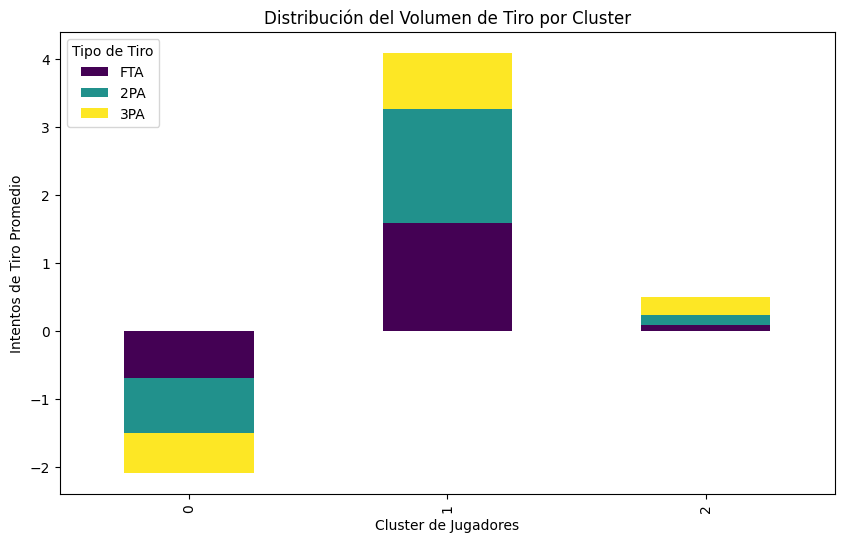

In [ ]:
import numpy as np

# Calcular el promedio de intentos de tiro por cluster
shot_metrics = df.groupby("Cluster")[["FTA", "2PA", "3PA"]].mean()

# Crear el gráfico de barras apiladas
shot_metrics.plot(kind="bar", stacked=True, figsize=(10,6), colormap="viridis")

plt.xlabel("Cluster de Jugadores")
plt.ylabel("Intentos de Tiro Promedio")
plt.title("Distribución del Volumen de Tiro por Cluster")
plt.legend(title="Tipo de Tiro", loc="upper left")

plt.show()


Efectivamente, la cantidad de tiros tomados en el Cluster 1 es muy superior a la del Cluster 2 por ejemplo, que tiene un mejor porcentaje de acierto, dejando a estos últimos como los jugadores que son titulares o de rol pero que no tienen tanta participación ofensiva.

Volviendo al primer gráfico que hicimos (lo reinsertaré aquí debajo)

Estas últimas conclusiones lo único que hacen es realzar la temporada 2015-16 de Stephen Curry, en la cual ganó merecidamente, y de manera unánime por única vez en la historia, el premio al jugador más valioso de la liga.
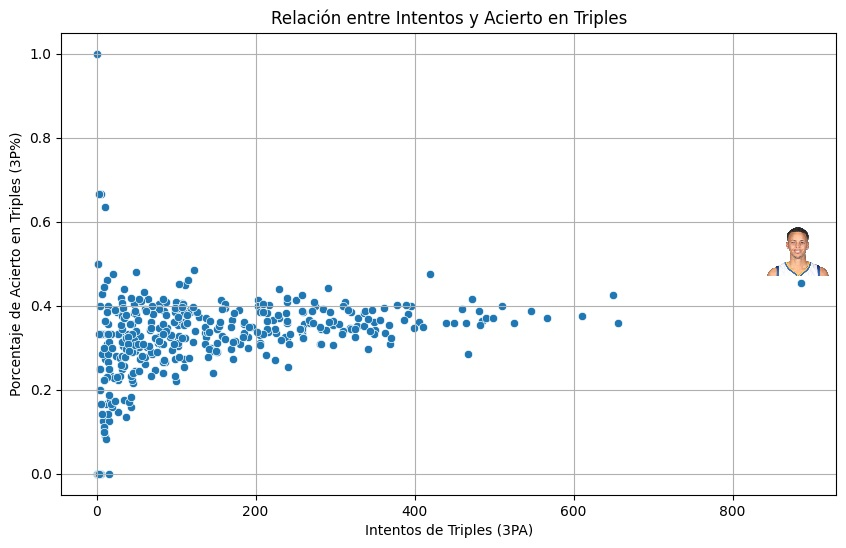

Haré un par de gráficos más, para ver que tan por encima estuvo Curry del resto.

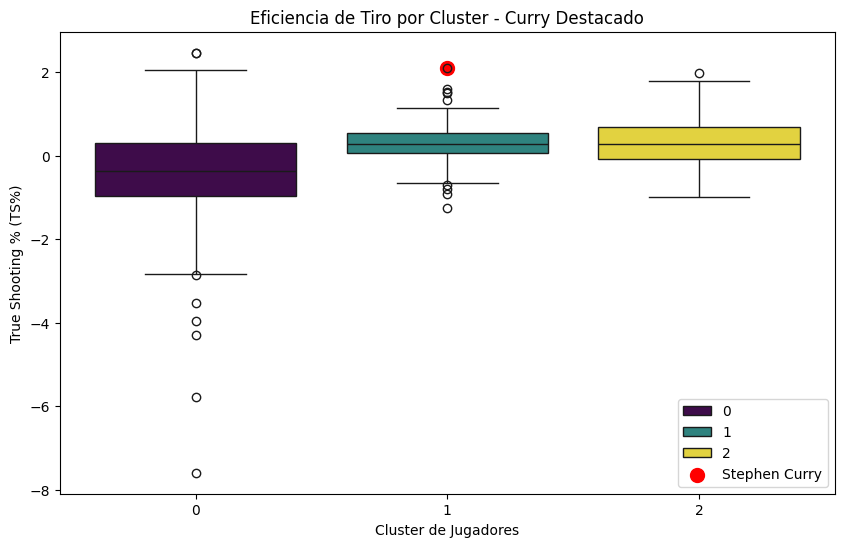

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Cluster", y="TS%", hue="Cluster", palette="viridis", dodge=False)

# Destacar a Curry con un punto rojo
curry = df[df["PLAYER"] == "Stephen Curry"]
plt.scatter(x=curry["Cluster"], y=curry["TS%"], color="red", s=100, label="Stephen Curry")

plt.xlabel("Cluster de Jugadores")
plt.ylabel("True Shooting % (TS%)")
plt.title("Eficiencia de Tiro por Cluster - Curry Destacado")
plt.legend()
plt.show()


Esto nos confirma que Curry se destacó dentro del grupo de las superestrellas, y si tomamos en cuenta la información que ya sabíamos, el cluster 1 es el que más tiros toma por partido. Lo que lo convierte en una máquina ofensiva de alto valor para su equipo.

Finalizaré el trabajo con un gráfico final que compare el volumen de tiros y la eficiencia de los mismos para ver donde se ubica Stephen

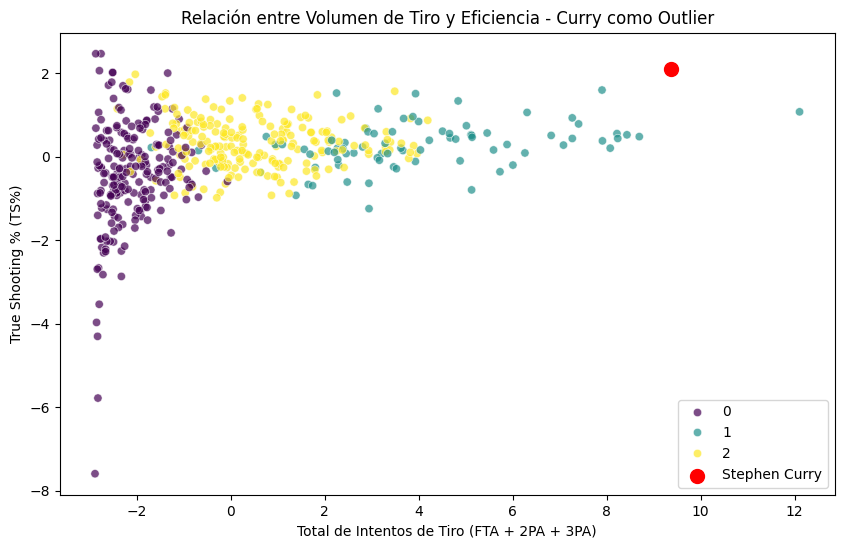

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate "Total Attempts" before creating the curry dataframe
df["Total Attempts"] = df["FTA"] + df["2PA"] + df["3PA"]

# Redefine curry after the new column has been added to df
curry = df[df["PLAYER"] == "Stephen Curry"]

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Total Attempts", y="TS%", hue="Cluster", palette="viridis", alpha=0.7)

# Destacar a Curry
plt.scatter(curry["Total Attempts"], curry["TS%"], color="red", s=100, label="Stephen Curry")

plt.xlabel("Total de Intentos de Tiro (FTA + 2PA + 3PA)")
plt.ylabel("True Shooting % (TS%)")
plt.title("Relación entre Volumen de Tiro y Eficiencia - Curry como Outlier")
plt.legend()
plt.show()

Como vemos claramente en el gráfico, Curry fue el 2do jugador que más tiros tomó, pero mantuvo un alto porcentaje de acierto durante toda la temporada, lo cual le alcanzó y sobró para ganar el premio al jugador más valioso de la 15-16 y a su vez llegar a las finales del campeonato, en las que perdieron contra los Cavaliers de Lebron James en una serie a puro drama que para los amantes del deporte vale mucho la pena recordar o volver a disfrutar de vez en cuando.

# Conclusión

El Clustering realizado permitió agrupar a los jugadores de la temporada 2015-2016 en distintos perfiles según su volumen de tiro, eficiencia y versatilidad ofensiva, lo que facilita la identificación de roles dentro de un equipo.



**Propuesta de Implementación:**

Este modelo podría utilizarse para evaluar jugadores en temporadas futuras, ayudando a equipos y analistas a identificar tendencias de rendimiento y predecir su impacto en la cancha. Además, al combinar esta clasificación con modelos de predicción, sería posible estimar la evolución de un jugador a lo largo del tiempo, optimizando decisiones estratégicas como las rotaciones de jugadores, la gestión de minutos o el scouting de posibles nuevos jugadores.

En cuanto a otros ámbitos, aplicar esta técnica o alguna similar sería de uso para identificar talentos, y así mejorar la asignación de roles en cualquier industria.

O bien para identificar distintos tipos de consumidores de X mercado y predecir tendencias de ventas y optimizar las estrategias de marketing.

**Propuesta de Mejora:**

Volviendo al contexto deportivo, podría explorarse la incorporación de más variables al modelo, como algunas estadísticas o métricas defensivas avanzadas, para obtener una visión aún más completa del impacto de cada jugador en su equipo.

Esto permitiría identificar no solo a quienes destacan por su producción ofensiva, sino también a aquellos que aportan desde la reducción de oportunidades de anotación de los rivales.